# Phase 2a-1. Macrophage subset & TAM subtype annotation

Phase 1에서 전체 폐암 scRNA-seq 데이터를 QC, normalization, HVG, PCA, Harmony, UMAP, Leiden, cell type annotation까지 완료했다.

이번 notebook의 목적은 전체 immune/TME cell 중 **Macrophage만 subset**한 뒤, macrophage 내부의 TAM subtype(C1QC+ TAM, SPP1+ TAM, ISG15+ TAM)을 marker gene 기반으로 확인하는 것이다.

핵심 질문:
- GSE127465 폐암 데이터에서도 논문에서 제시한 C1QC+ TAM / SPP1+ TAM 패턴이 보이는가?
- 단일 폐암 데이터에서 ISG15+ TAM도 독립적으로 분리되는가?


## 0. Helper — AnnData 상태 검증 함수

단순히 plot이 나오는지만 보는 것이 아니라, 각 단계에서 `adata/mac` 내부 상태가 의도대로 바뀌었는지 확인한다.

확인 항목:
- shape: 세포 수 × 유전자 수
- `X` type/dtype: sparse/float32 유지 여부
- `obs/var` unique: barcode/gene 중복 여부
- `obsm/obsp/uns`: PCA, UMAP, neighbors graph 저장 여부
- 주요 obs 컬럼 존재 여부


In [19]:
import scanpy as sc
import pandas as pd
import numpy as np
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))
from utils.paths import *
from utils.report import ph2_report_adata_state

## 1. Phase 1 결과 불러오기

Phase 1에서 이미 전체 cell type annotation까지 완료한 `GSE127465_human_final.h5ad`를 불러온다.

여기서의 `cell_type`은 대분류 annotation이고, Phase 2에서는 Macrophage 내부를 다시 세분화해 `tam_subtype`을 추가한다.


In [20]:
adata = sc.read_h5ad(HUMAN_H5AD)
ph2_report_adata_state(adata, 'Phase 1 annotated data')
print(adata.obs['cell_type'].value_counts())

===== Phase 1 annotated data =====
shape: 44,860 cells x 2,000 genes
X type: <class 'numpy.ndarray'>
X dtype: float64
obs names unique: True
var names unique: True
obs columns: ['n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'n_counts', 'sample', 'leiden', 'cell_type']
obsm keys: ['X_pca', 'X_pca_harmony', 'X_umap']
obsp keys: ['connectivities', 'distances']
layers keys: ['counts']
uns keys: ['cell_type_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'umap']

cell_type
Unknown        14937
T cell         12705
Macrophage      9567
B cell          4572
Cancer cell     3079
Name: count, dtype: int64


## 2. 왜 Macrophage만 subset해서 재클러스터링하는가?

전체 cell 상태에서는 T cell, B cell, epithelial/tumor cell, macrophage 같은 큰 cell type 차이가 PCA/neighbor graph의 주요 variance를 차지한다.

하지만 Phase 2에서 보고 싶은 것은 macrophage 내부의 subtype 차이(C1QC+ TAM vs SPP1+ TAM)다. 전체 cell 기준 embedding에서는 이런 미세한 macrophage 내부 signal이 큰 cell type variance에 묻힐 수 있다.

따라서 Macrophage만 subset한 뒤 PCA/neighbor/UMAP/Leiden을 다시 수행하여 **macrophage 내부 구조에 최적화된 embedding space**를 새로 만든다.

단순히 전체 데이터에서 resolution만 올리는 방식은 graph 자체가 전체 cell 기준으로 만들어진 상태이기 때문에 noise cluster, fragmented cluster, meaningless tiny cluster를 늘릴 위험이 있다.


In [21]:
mac = adata[adata.obs['cell_type'] == 'Macrophage'].copy()
ph2_report_adata_state(mac, 'Macrophage subset')
print(mac.obs['cell_type'].value_counts())

===== Macrophage subset =====
shape: 9,567 cells x 2,000 genes
X type: <class 'numpy.ndarray'>
X dtype: float64
obs names unique: True
var names unique: True
obs columns: ['n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'n_counts', 'sample', 'leiden', 'cell_type']
obsm keys: ['X_pca', 'X_pca_harmony', 'X_umap']
obsp keys: ['connectivities', 'distances']
layers keys: ['counts']
uns keys: ['cell_type_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'umap']

cell_type
Macrophage    9567
Name: count, dtype: int64


## 3. Macrophage subset 재클러스터링

Phase 1에서 생성된 Harmony 보정 PCA embedding(`X_pca_harmony`)을 사용하여 macrophage subset 내부에서 neighbor graph를 다시 만든다.

function 설명:
- `neighbors`: 세포 간 graph 저장 단계
- `umap`: graph 기반 2D 시각화
- `leiden`: graph 기반 community detection으로 cluster label 생성

재현성 강화
- ``random_state = 42``를 각 단계마다(neighbor, umap, leiden) 부여하게 되면 각 stochastic process가 fix됨
- 결과 variance가 감소하고 return 안정성이 증가함

===== After macrophage reclustering =====
shape: 9,567 cells x 2,000 genes
X type: <class 'numpy.ndarray'>
X dtype: float64
obs names unique: True
var names unique: True
obs columns: ['n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'n_counts', 'sample', 'leiden', 'cell_type']
obsm keys: ['X_pca', 'X_pca_harmony', 'X_umap']
obsp keys: ['connectivities', 'distances']
layers keys: ['counts']
uns keys: ['cell_type_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'umap']

Leiden cluster count: 10
leiden
0    1501
1    1471
2    1419
3    1081
4    1080
5     978
6     845
7     667
8     319
9     206
Name: count, dtype: int64


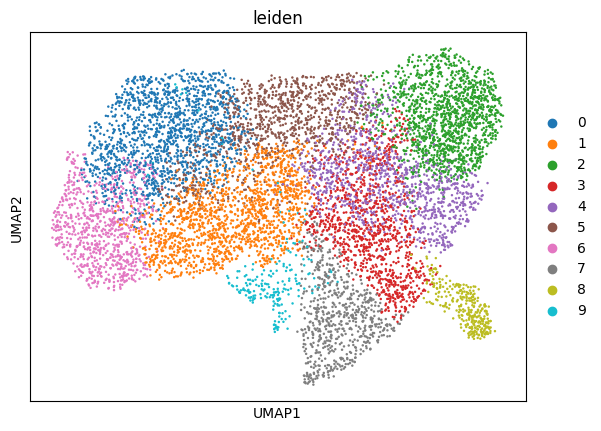

In [24]:
sc.pp.neighbors(mac, use_rep='X_pca_harmony', n_pcs=17, random_state=42)
sc.tl.umap(mac, random_state=42)
sc.tl.leiden(mac, resolution=0.5, random_state=42)

ph2_report_adata_state(mac, 'After macrophage reclustering')
print('Leiden cluster count:', mac.obs['leiden'].nunique())
print(mac.obs['leiden'].value_counts().sort_index())

sc.pl.umap(mac, color='leiden')

## 4. TAM subtype marker gene 발현 확인

논문에서 제시한 TAM subtype marker를 기준으로 C1QC+ TAM, SPP1+ TAM, ISG15+ TAM이 macrophage subset 안에서 어디에 위치하는지 확인한다.

- C1QC: tissue-resident/homeostatic macrophage 계열 marker
- SPP1: tumor-associated remodeling / immunosuppressive macrophage 계열 marker
- ISG15: interferon-stimulated macrophage state marker

`use_raw=True`를 사용하여 HVG filtering 이후 사라졌을 수 있는 marker gene도 raw normalized matrix에서 조회할 수 있게 한다.

Missing markers in mac.raw: []


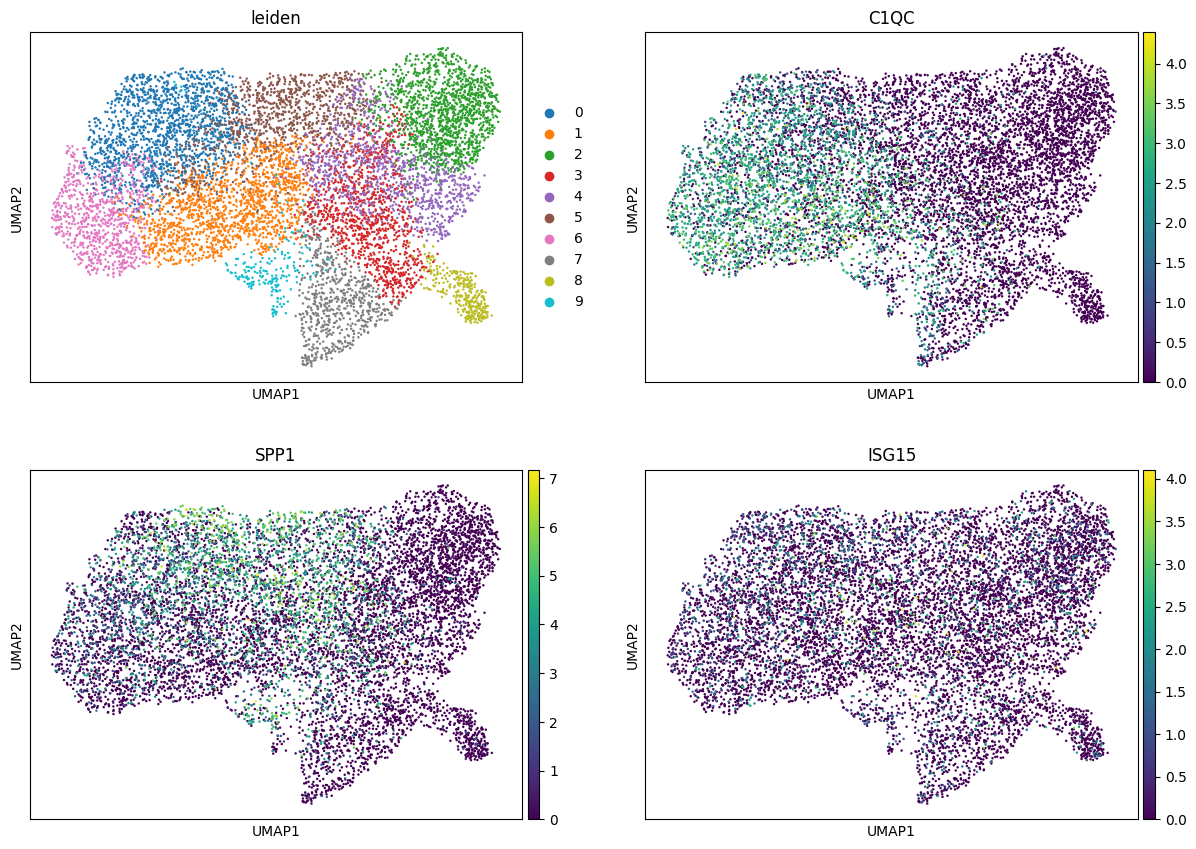

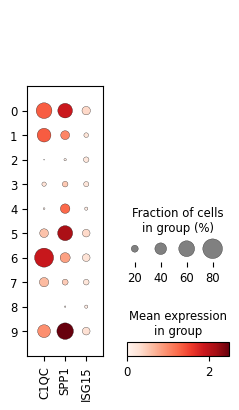

In [25]:
tam_markers = ['C1QC', 'SPP1', 'ISG15']
missing_markers = [g for g in tam_markers if g not in mac.raw.var_names]
print('Missing markers in mac.raw:', missing_markers)

sc.pl.umap(mac, color=['leiden', 'C1QC', 'SPP1', 'ISG15'], ncols=2, use_raw=True)
sc.pl.dotplot(mac, tam_markers, groupby='leiden', use_raw=True)

## 5. Marker 기반 TAM subtype annotation

UMAP과 dotplot을 함께 확인하여 marker 발현이 뚜렷한 cluster에 TAM subtype label을 부여한다.

annotation base-line을 Fraction of cells or Mean expression?
- 일반적으로는 fraction을 더 우선적으로,
- 후에 mean expression intensity 고려

Fraction of cells:
- 해당 cluster 안에서 몇 %의 세포가 이 유전자를 발현하나?
Mean expression:
- 발현하는 세포들의 평균 발현량이 얼마나 강한가?

현재 기준:
- cluster 6 → C1QC+ TAM
- cluster 9 → SPP1+ TAM
- ISG15+ TAM은 단일 폐암 데이터에서 독립 cluster로 뚜렷하게 분리되지 않아 annotation하지 않음

sub:
- 0 -> C1QC/SPP1 intermediate or mixed TAM
- 5 -> SPP1-like TAM 후보
- 1 -> C1QC-like TAM 후보

issue 발생:
- 0, 9번 cluster가 양쪽 marker에 걸쳐 있음
- 이 cluster들을 단순히 C1QC+ 또는 SPP1+로 확정하는 것이 맞는 건지 의심됨

=> 단일 gene으로 가는 것 보다 ``gene set score``를 보는 방법을 선택

In [ ]:
candidate_c1qc_markers = ["C1QC", "APOE", "APOC1", "SELENOP"]
candidate_spp1_markers = ["SPP1", "GPNMB", "CTSD", "MRC1", "CD63"]

print("C1QC candidates:")
print([g for g in candidate_c1qc_markers if g in mac.var_names])

print("SPP1 candidates:")
print([g for g in candidate_spp1_markers if g in mac.var_names])

print("Missing C1QC candidates:")
print([g for g in candidate_c1qc_markers if g not in mac.var_names])

print("Missing SPP1 candidates:")
print([g for g in candidate_spp1_markers if g not in mac.var_names])

Valid C1QC markers: ['C1QC', 'APOE', 'APOC1', 'SELENOP']
Valid SPP1 markers: ['SPP1', 'GPNMB', 'CTSD', 'MRC1', 'CD63']


results:
- mac.var_names에 후보 유전자들이 누락없이 모두 들어가 있음

즉,
- marker set 정상
- gene naming 문제 없음
- human gene symbol 매칭 정상
- score_genes 진행 가능
상태이다

Valid C1QC markers: ['C1QC', 'APOE', 'APOC1', 'SELENOP']
Valid SPP1 markers: ['SPP1', 'GPNMB', 'CTSD', 'MRC1', 'CD63']


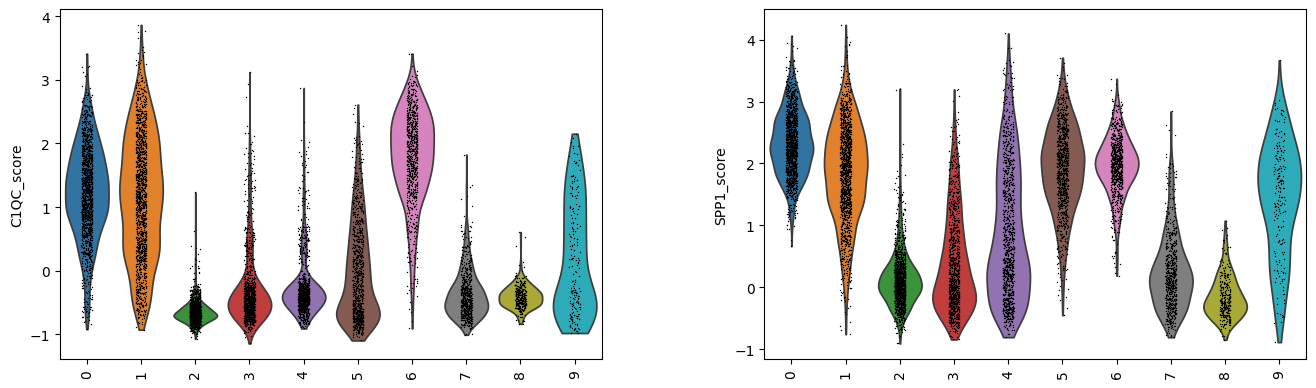

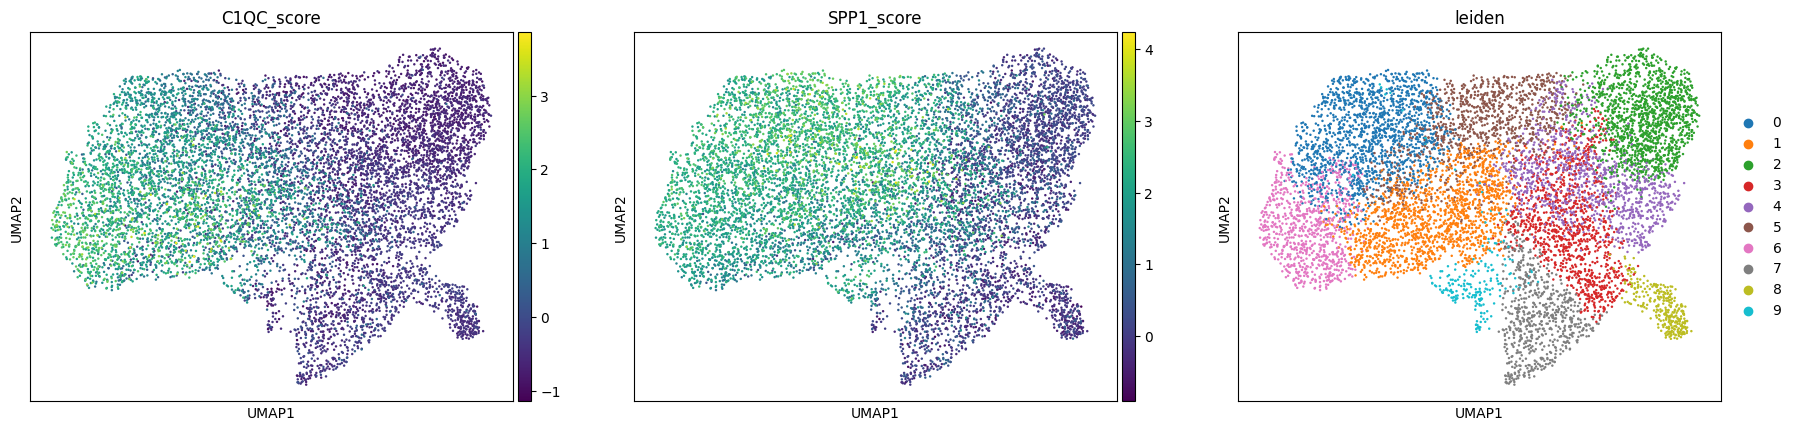

In [32]:
c1qc_markers = [g for g in candidate_c1qc_markers if g in mac.var_names]
spp1_markers = [g for g in candidate_spp1_markers if g in mac.var_names]

print("Valid C1QC markers:", c1qc_markers)
print("Valid SPP1 markers:", spp1_markers)

if c1qc_markers:
    sc.tl.score_genes(mac, c1qc_markers, score_name="C1QC_score")

if spp1_markers:
    sc.tl.score_genes(mac, spp1_markers, score_name="SPP1_score")
    
sc.pl.violin(mac, ["C1QC_score", "SPP1_score"], groupby="leiden", rotation=90)
sc.pl.umap(mac, color=["C1QC_score", "SPP1_score", "leiden"])

### results
C1QC+ TAM:
- cluster 6: dotplot에서 가장 크고 진함, SPP1/ISG15 낮음 -> 가장 명확한 C1QC core
- cluster 0: dotplot 중간+, violin C1QC_score 높음, UMAP 왼쪽 상단 C1QC high 영역에 위치 -> C1QC TAM
- cluster 1: 0과 비슷하나 UMAP 대조 결과 판단 후 tentative로 다운그레이드

SPP1+ TAM:
- cluster 9: dotplot에서 SPP1 가장 크고 진함, ISG15 중간+, C1QC 낮음 -> 가장 명확한 SPP1 core
- cluster 5: dotplot SPP1 중간, violin SPP1_score 중간, UMAP SPP1 high 영역 -> SPP1 TAM 후보 (약함)

ISG15 TAM
- 세 지표 모두에서 유의미한 신호 없음. 단일 암종(NSCLC) 한계로 예상된 결과

Unresolved (2, 3, 4, 7, 8)
- C1QC/SPP1/ISG15 전부 낮음. 세 marker만으로는 판단 불가. monocyte 또는 다른 myeloid subtype 가능성

현재 기준:
- cluster 6, 0 → C1QC+ TAM\
- cluster 1 → C1QC+ TAM (tentative)
- cluster 9 → SPP1+ TAM
- cluster 5 → SPP1+ TAM (tentative)
- ISG15+ TAM은 단일 폐암 데이터에서 독립 cluster로 뚜렷하게 분리되지 않아 annotation하지 않음

이 결과는 C1QC+ TAM / SPP1+ TAM 패턴은 GSE127465 폐암 데이터에서도 관찰되지만, ISG15+ TAM은 pan-cancer 통합 수준에서 더 뚜렷할 수 있음을 시사한다.

tam_subtype
Unknown                  4566
C1QC+ TAM                2346
C1QC+ TAM (tentative)    1471
SPP1+ TAM (tentative)     978
SPP1+ TAM                 206
Name: count, dtype: int64
tam_subtype
Unknown                  47.73
C1QC+ TAM                24.52
C1QC+ TAM (tentative)    15.38
SPP1+ TAM (tentative)    10.22
SPP1+ TAM                 2.15
Name: proportion, dtype: float64


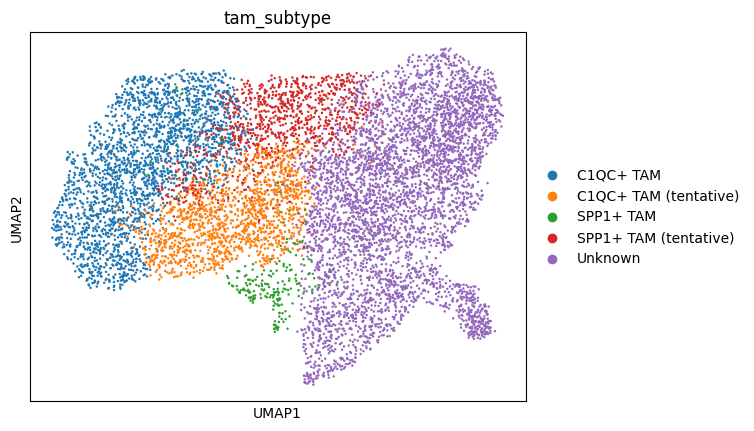

In [36]:
mac.obs['tam_subtype'] = mac.obs['leiden'].map({
    '6': 'C1QC+ TAM',
    '0': 'C1QC+ TAM',
    '1': 'C1QC+ TAM (tentative)',
    '9': 'SPP1+ TAM',
    '5': 'SPP1+ TAM (tentative)',
}).fillna('Unknown')

print(mac.obs['tam_subtype'].value_counts())
print((mac.obs['tam_subtype'].value_counts(normalize=True) * 100).round(2))

sc.pl.umap(mac, color='tam_subtype')

## 6. 중간 결과 저장

다음 notebook(`02_DEG_analysis.ipynb`)에서 DEG 분석을 수행하기 위해 TAM subtype annotation이 추가된 macrophage subset을 저장한다.

In [38]:
mac.write_h5ad(MAC_SUB_H5AD)
print(f'저장 완료: {MAC_SUB_H5AD}')

저장 완료: dataset\GSE127465_mac_subtyped.h5ad
